In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

### 1 Congestion Pricing Reduces Overall Travel but Increases Public Transit

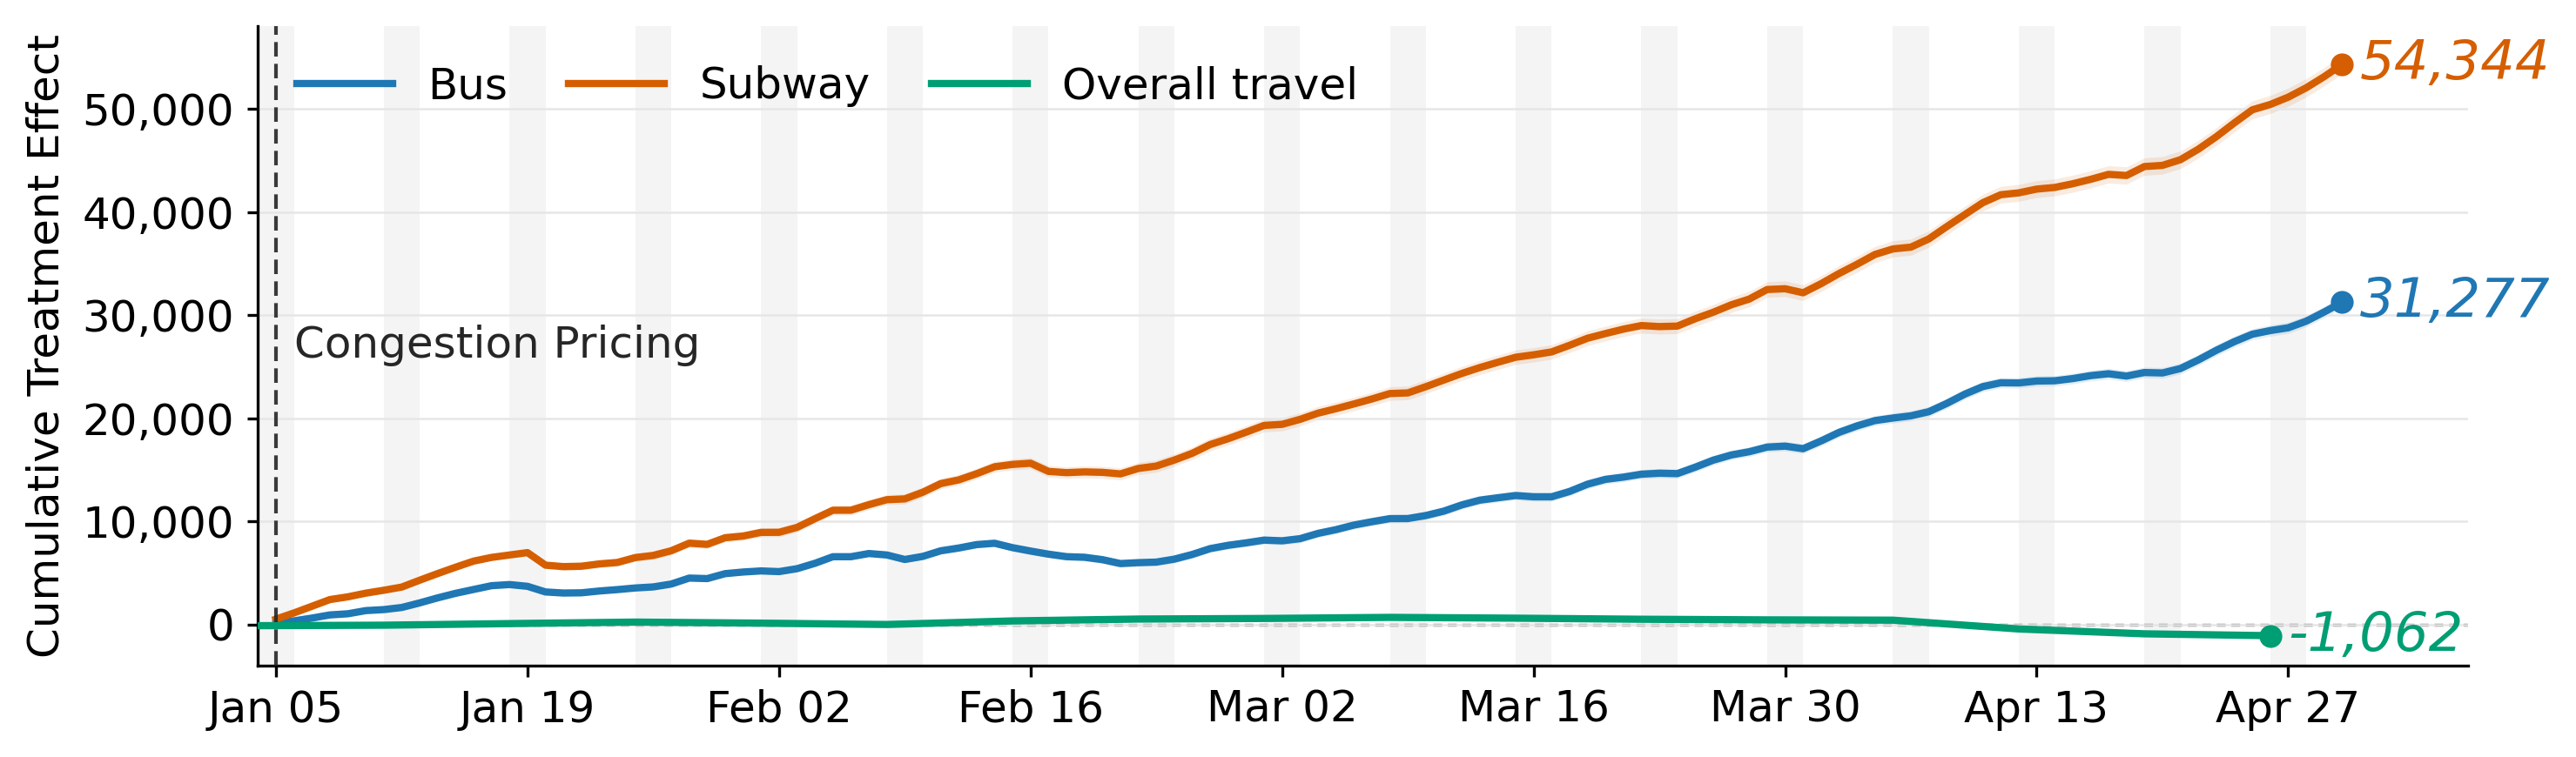

In [ ]:
# %% Imports
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter

# %% Load cumulative ATT data
bus = pd.read_csv(
    "/public_dataset/donghang/nyc_congestion_pricing/output_new/bus/timesfm_qrcal_intercept/effects/bus_timesfm_qrcal_intercept_test_daily.csv"
)

subway = pd.read_csv(
    "/public_dataset/donghang/nyc_congestion_pricing/output_new/subway/timesfm_qrcal_intercept/total/effects/subway_timesfm_qrcal_intercept_test_total_daily.csv"
)

replica = pd.read_csv(
    "/public_dataset/donghang/nyc_congestion_pricing/output_new/replica/timesfm_qrcal_intercept/O/effects/replica_timesfm_qrcal_intercept_test_O_daily.csv"
)

# %% Preprocess
datasets = {
    "Bus": {
        "df": bus,
        "color": "#1F77B4",
    },
    "Subway": {
        "df": subway,
        "color": "#D55E00",
    },
    "Overall travel": {
        "df": replica,
        "color": "#009E73",
    },
}

for item in datasets.values():
    item["df"]["date"] = pd.to_datetime(item["df"]["date"])
    item["df"] = item["df"].sort_values("date")

# %% Plot cumulative ATT
fig, ax = plt.subplots(figsize=(12, 3), dpi=300)

policy_date = pd.Timestamp("2025-01-05")

all_dates = pd.concat([item["df"]["date"] for item in datasets.values()])
date_min = all_dates.min()
date_max = all_dates.max()

# Weekend shading
weekend_days = pd.date_range(date_min, date_max, freq="D")
for day in weekend_days:
    if day.weekday() == 5:
        ax.axvspan(
            day,
            day + pd.Timedelta(days=2),
            color="0.92",
            alpha=0.55,
            lw=0,
            zorder=0,
        )

# Cumulative ATT curves
for mode, item in datasets.items():
    df = item["df"]
    color = item["color"]

    ax.fill_between(
        df["date"],
        df["cum_eff_lo"],
        df["cum_eff_hi"],
        color=color,
        alpha=0.12,
        lw=0,
        zorder=1,
    )

    ax.plot(
        df["date"],
        df["cum_tau"],
        color=color,
        lw=2.0,
        label=mode,
        zorder=3,
    )

    ax.scatter(
        df["date"].iloc[-1],
        df["cum_tau"].iloc[-1],
        color=color,
        s=28,
        zorder=4,
    )

    ax.text(
        df["date"].iloc[-1] + pd.Timedelta(days=1),
        df["cum_tau"].iloc[-1],
        f"{df['cum_tau'].iloc[-1]:,.0f}",
        color=color,
        fontsize=15,
        va="center",
        ha="left",
        fontstyle="italic",
        zorder=5,
    )

# Zero line
ax.axhline(
    0,
    color="0.25",
    lw=0.8,
    ls=(0, (3, 2)),
    alpha=0.8,
    zorder=0,
)

# Congestion pricing start line
ax.axvline(
    policy_date,
    color="0.15",
    lw=1.0,
    ls=(0, (4, 2)),
    alpha=0.9,
    zorder=6,
)

ylim = ax.get_ylim()
y_mid = (ylim[0] + ylim[1]) / 2

ax.text(
    policy_date + pd.Timedelta(days=1),
    y_mid,
    "Congestion Pricing",
    color="0.15",
    fontsize=12,
    ha="left",
    va="center",
    zorder=7,
)

ax.set_ylabel("Cumulative Treatment Effect", fontsize=12)

ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:,.0f}"))

ax.xaxis.set_major_locator(mdates.DayLocator(interval=14))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

ax.tick_params(axis="x", rotation=0, labelsize=12)
ax.tick_params(axis="y", labelsize=12)
ax.tick_params(axis="both", length=3, width=0.8)

ax.grid(axis="y", color="0.9", lw=0.6)
ax.grid(axis="x", visible=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(0.8)
ax.spines["bottom"].set_linewidth(0.8)

ax.legend(
    loc="upper left",
    ncol=3,
    frameon=False,
    handlelength=2.2,
    columnspacing=1.4,
    fontsize=12,
)

ax.set_xlim(date_min, date_max + pd.Timedelta(days=7))

fig.tight_layout()
plt.show()

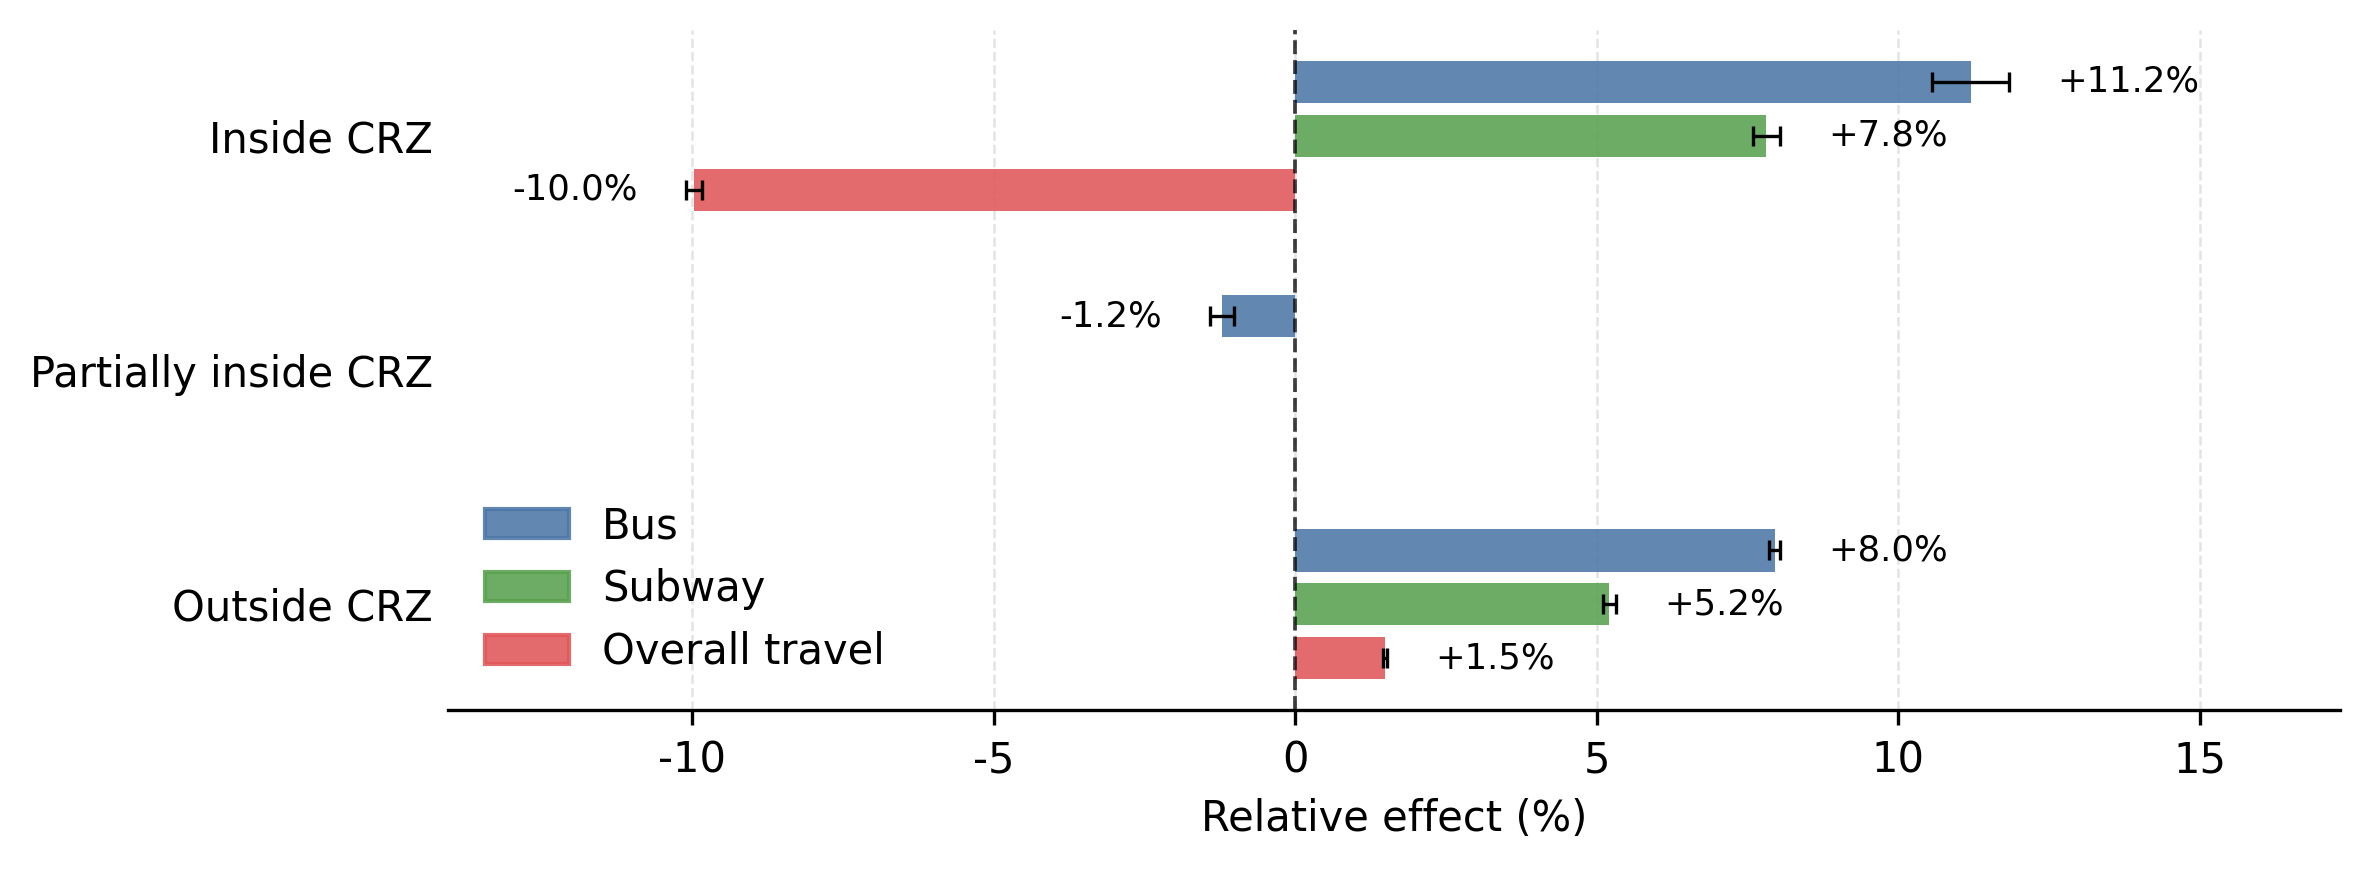

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

bus = pd.read_csv("/public_dataset/donghang/nyc_congestion_pricing/output_new/bus/timesfm_qrcal_intercept/causal/crz_summary.csv")
subway = pd.read_csv("/public_dataset/donghang/nyc_congestion_pricing/output_new/subway/timesfm_qrcal_intercept/total/causal/crz_summary.csv")
replica = pd.read_csv("/public_dataset/donghang/nyc_congestion_pricing/output_new/replica/timesfm_qrcal_intercept/O/causal/crz_summary.csv")

datasets = {
    "Bus": bus,
    "Subway": subway,
    "Overall travel": replica,
}

colors = {
    "Bus": "#4C78A8",
    "Subway": "#59A14F",
    "Overall travel": "#E15759",
}

crz_mapping = {
    "fully_inside": "Inside CRZ",
    "partially_inside": "Partially inside CRZ",
    "fully_outside": "Outside CRZ",
    "Inside CRZ": "Inside CRZ",
    "Outside CRZ": "Outside CRZ",
}

class_order = [
    "Inside CRZ",
    "Partially inside CRZ",
    "Outside CRZ",
]

mode_offsets = {
    "Bus": -0.23,
    "Subway": 0.00,
    "Overall travel": 0.23,
}

plot_rows = []

for mode, df in datasets.items():
    df = df.copy()

    df["crz_plot"] = df["crz_class"].map(crz_mapping)

    df["effect_pct"] = df["pooled_relative_effect"] * 100
    df["lo_pct"] = df["pooled_rel_lo"] * 100
    df["hi_pct"] = df["pooled_rel_hi"] * 100

    df = df[df["crz_plot"].isin(class_order)]

    for _, row in df.iterrows():
        plot_rows.append({
            "mode": mode,
            "crz": row["crz_plot"],
            "effect_pct": row["effect_pct"],
            "lo_pct": row["lo_pct"],
            "hi_pct": row["hi_pct"],
        })

plot_df = pd.DataFrame(plot_rows)

fig, ax = plt.subplots(figsize=(8, 3), dpi=300)

bar_height = 0.18
text_pad = 0.8

for _, row in plot_df.iterrows():
    y = class_order.index(row["crz"]) + mode_offsets[row["mode"]]
    x = row["effect_pct"]

    xerr = np.array([
        [x - row["lo_pct"]],
        [row["hi_pct"] - x]
    ])

    ax.barh(
        y,
        x,
        height=bar_height,
        color=colors[row["mode"]],
        alpha=0.88,
        zorder=2
    )

    ax.errorbar(
        x,
        y,
        xerr=xerr,
        fmt="none",
        ecolor="black",
        elinewidth=0.8,
        capsize=2.5,
        capthick=0.8,
        zorder=3
    )

    text_x = row["hi_pct"] + text_pad if x >= 0 else row["lo_pct"] - text_pad

    ax.text(
        text_x,
        y,
        f"{x:+.1f}%",
        va="center",
        ha="left" if x >= 0 else "right",
        fontsize=8.5
    )

ax.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=0.9,
    alpha=0.75
)

ax.set_yticks(np.arange(len(class_order)))
ax.set_yticklabels(class_order)
ax.invert_yaxis()

ax.set_xlabel("Relative effect (%)")

ax.grid(axis="x", linestyle="--", linewidth=0.6, alpha=0.35)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.tick_params(axis="y", length=0)

x_min = plot_df["lo_pct"].min()
x_max = plot_df["hi_pct"].max()
x_range = x_max - x_min

ax.set_xlim(
    x_min - 0.18 * x_range,
    x_max + 0.25 * x_range
)

legend_handles = [
    plt.Rectangle((0, 0), 1, 1, color=colors["Bus"], alpha=0.88),
    plt.Rectangle((0, 0), 1, 1, color=colors["Subway"], alpha=0.88),
    plt.Rectangle((0, 0), 1, 1, color=colors["Overall travel"], alpha=0.88),
]

ax.legend(
    legend_handles,
    ["Bus", "Subway", "Overall travel"],
    frameon=False,
    loc="lower left"
)

plt.tight_layout()
plt.show()

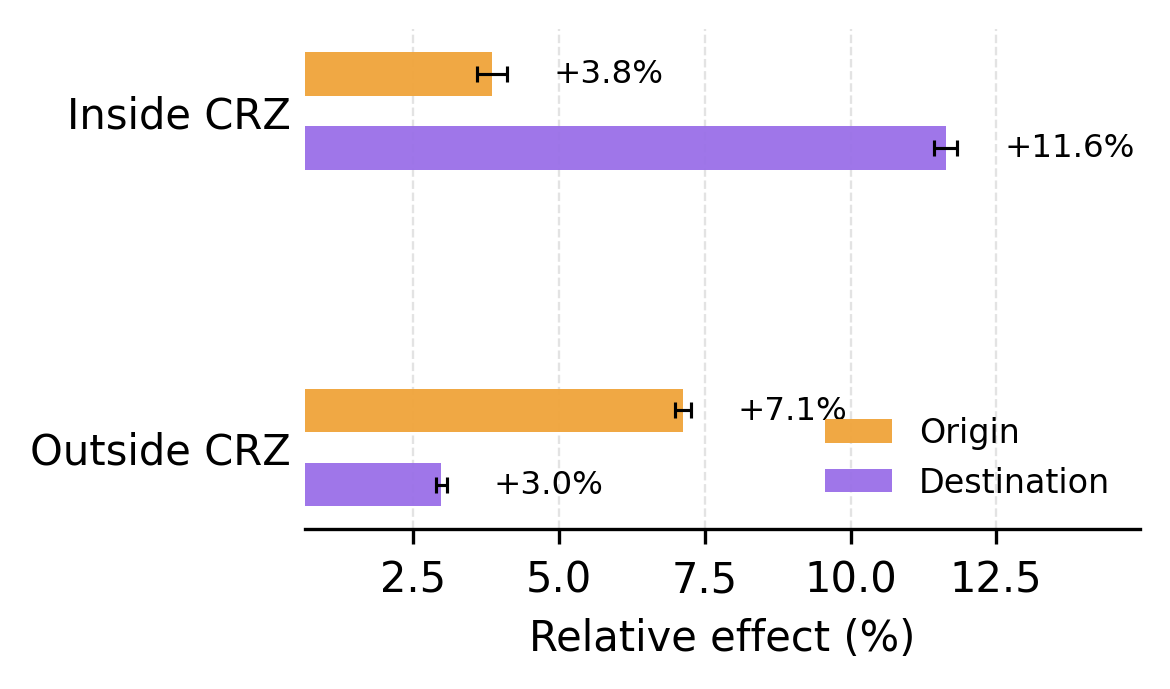

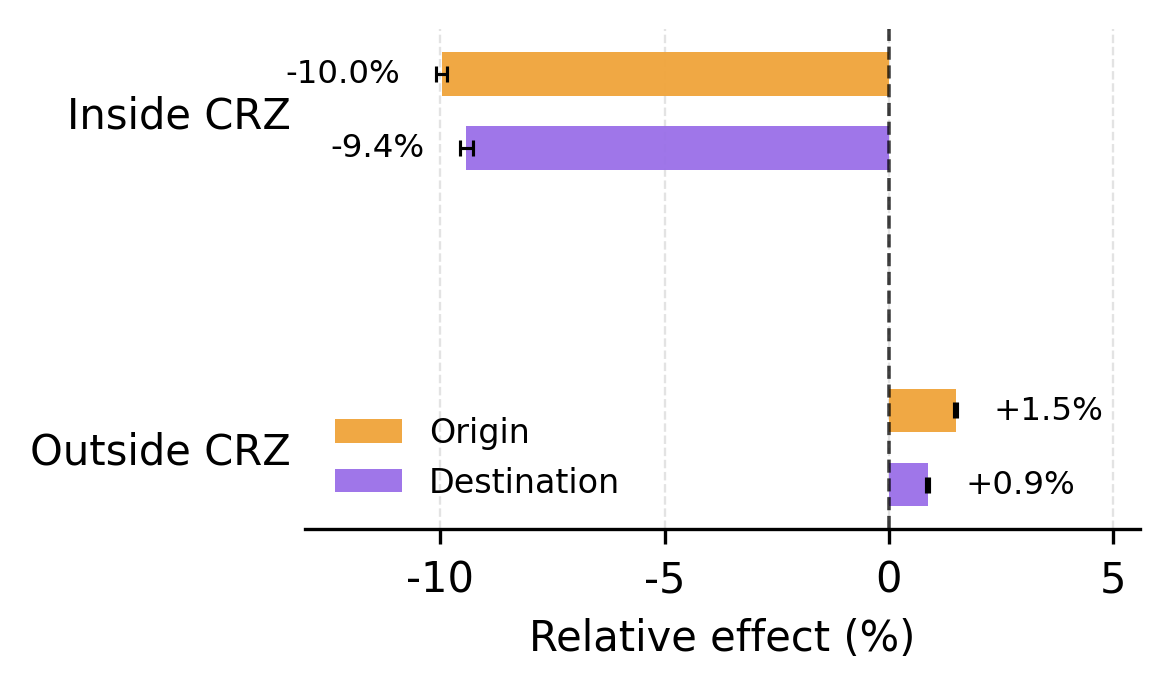

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

subway_o = pd.read_csv("/public_dataset/donghang/nyc_congestion_pricing/output_new/subway/timesfm_qrcal_intercept/O/causal/crz_summary.csv")
subway_d = pd.read_csv("/public_dataset/donghang/nyc_congestion_pricing/output_new/subway/timesfm_qrcal_intercept/D/causal/crz_summary.csv")

replica_o = pd.read_csv("/public_dataset/donghang/nyc_congestion_pricing/output_new/replica/timesfm_qrcal_intercept/O/causal/crz_summary.csv")
replica_d = pd.read_csv("/public_dataset/donghang/nyc_congestion_pricing/output_new/replica/timesfm_qrcal_intercept/D/causal/crz_summary.csv")

crz_order = ["Inside CRZ", "Outside CRZ"]
group_order = ["Origin", "Destination"]

colors = {
    "Origin": "#F0A43A",
    "Destination": "#9A6FE8",
}

def prepare_df(df, group):
    df = df.copy()
    df = df[df["crz_class"].isin(crz_order)]

    df["group"] = group
    df["effect_pct"] = df["pooled_relative_effect"] * 100
    df["lo_pct"] = df["pooled_rel_lo"] * 100
    df["hi_pct"] = df["pooled_rel_hi"] * 100

    return df[["crz_class", "group", "effect_pct", "lo_pct", "hi_pct"]]


def plot_horizontal_crz_effect(df_o, df_d, legend_loc="lower left"):
    plot_df = pd.concat(
        [
            prepare_df(df_o, "Origin"),
            prepare_df(df_d, "Destination"),
        ],
        ignore_index=True
    )

    plot_df["crz_class"] = pd.Categorical(
        plot_df["crz_class"],
        categories=crz_order,
        ordered=True
    )

    plot_df["group"] = pd.Categorical(
        plot_df["group"],
        categories=group_order,
        ordered=True
    )

    plot_df = plot_df.sort_values(["crz_class", "group"])

    fig, ax = plt.subplots(figsize=(4, 2.4), dpi=300)

    y_base = np.arange(len(crz_order))
    bar_height = 0.13

    offsets = {
        "Origin": -0.11,
        "Destination": 0.11,
    }

    text_pad = 0.8

    for group in group_order:
        sub = plot_df[plot_df["group"] == group].copy()
        sub = sub.sort_values("crz_class")

        y = y_base + offsets[group]
        x = sub["effect_pct"].values

        xerr = np.vstack([
            x - sub["lo_pct"].values,
            sub["hi_pct"].values - x
        ])

        ax.barh(
            y,
            x,
            height=bar_height,
            color=colors[group],
            alpha=0.95,
            label=group,
            zorder=2
        )

        ax.errorbar(
            x,
            y,
            xerr=xerr,
            fmt="none",
            ecolor="black",
            elinewidth=0.75,
            capsize=2.0,
            capthick=0.75,
            zorder=3
        )

        for xi, yi, lo, hi in zip(x, y, sub["lo_pct"].values, sub["hi_pct"].values):
            text_x = hi + text_pad if xi >= 0 else lo - text_pad

            ax.text(
                text_x,
                yi,
                f"{xi:+.1f}%",
                va="center",
                ha="left" if xi >= 0 else "right",
                fontsize=7.8
            )

    ax.axvline(0, color="black", linestyle="--", linewidth=0.85, alpha=0.75)

    ax.set_yticks(y_base)
    ax.set_yticklabels(crz_order)
    ax.invert_yaxis()

    ax.set_xlabel("Relative effect (%)")
    ax.grid(axis="x", linestyle="--", linewidth=0.55, alpha=0.35)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)

    ax.tick_params(axis="y", length=0)

    x_min = plot_df["lo_pct"].min()
    x_max = plot_df["hi_pct"].max()
    x_range = x_max - x_min

    ax.set_xlim(
        x_min - 0.25 * x_range,
        x_max + 0.35 * x_range
    )

    ax.legend(
        frameon=False,
        loc=legend_loc,
        fontsize=8
    )

    plt.tight_layout()
    plt.show()


plot_horizontal_crz_effect(subway_o, subway_d, legend_loc="lower right")
plot_horizontal_crz_effect(replica_o, replica_d, legend_loc="lower left")

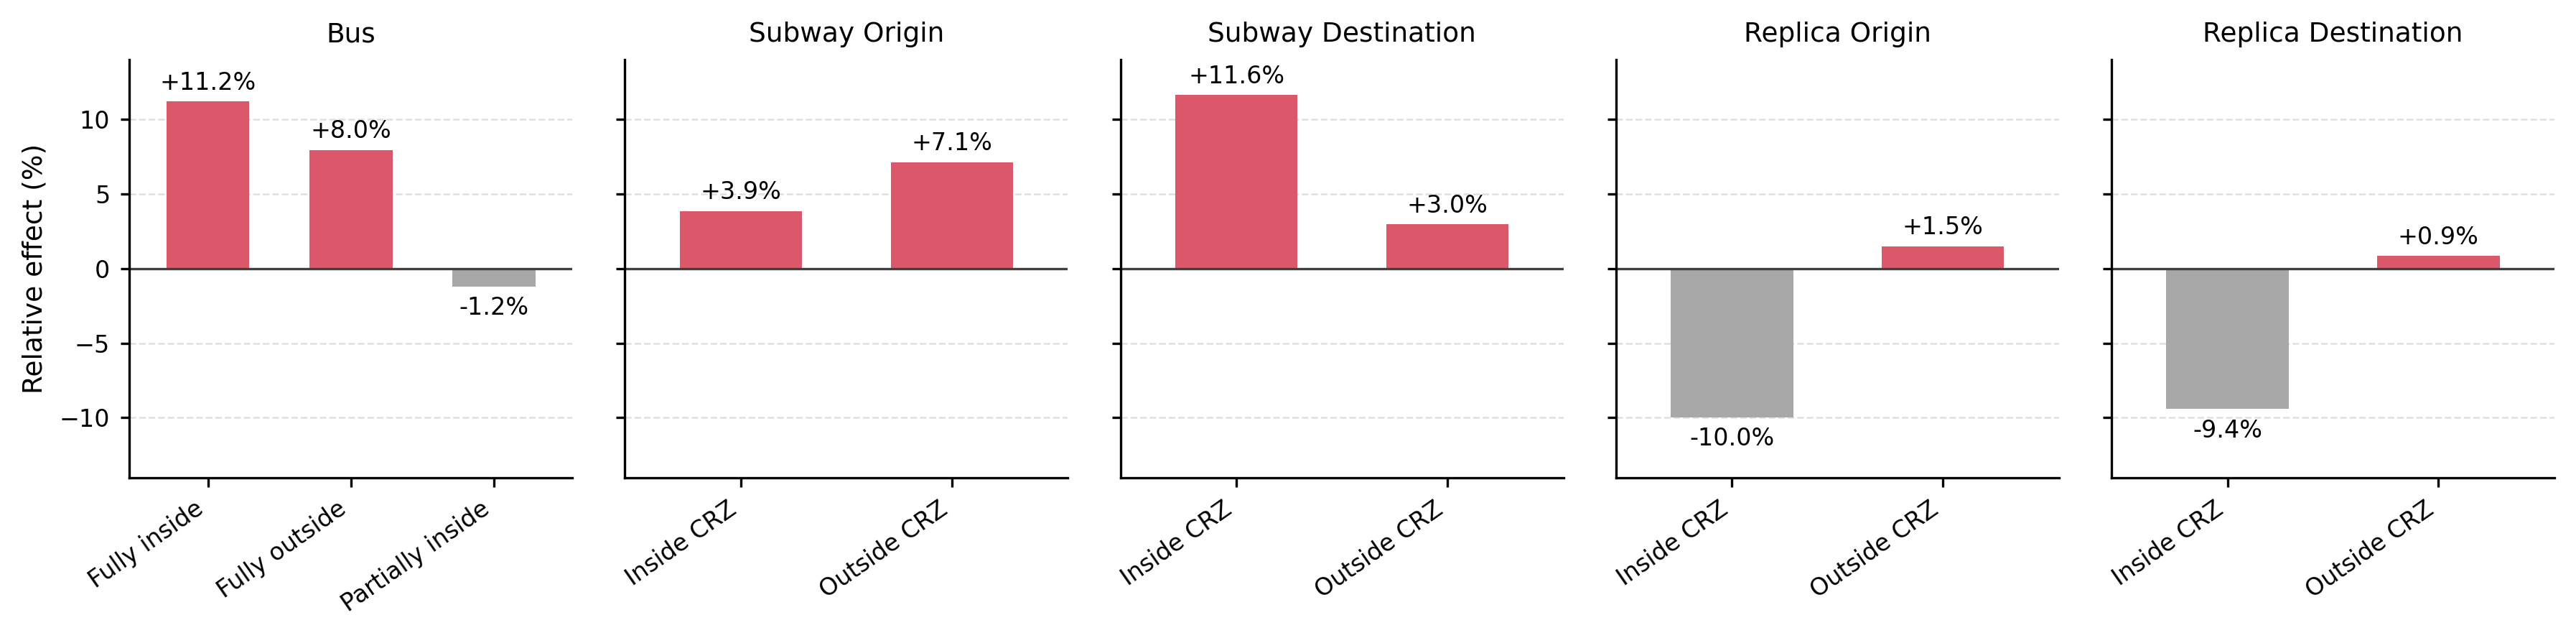

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    "font.size": 8,
    "axes.titlesize": 9,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

data = [
    ["Bus", "All", "Fully inside", 10, 8, 2, 41206, 22436, 11.21],
    ["Bus", "All", "Fully outside", 382, 282, 40, 39260, 26680, 7.95],
    ["Bus", "All", "Partially inside", 58, 26, 20, -9022, 4965, -1.21],
    ["Subway", "Origin", "Inside CRZ", 89, 57, 20, 51126, 39066, 3.85],
    ["Subway", "Origin", "Outside CRZ", 335, 229, 63, 55760, 27637, 7.13],
    ["Subway", "Destination", "Inside CRZ", 89, 41, 44, 142740, -9993, 11.63],
    ["Subway", "Destination", "Outside CRZ", 335, 108, 212, 24329, -47911, 2.98],
    ["Replica", "Origin", "Inside CRZ", 110, 20, 84, -67131, -51771, -9.97],
    ["Replica", "Origin", "Outside CRZ", 1848, 843, 784, 2871, 370, 1.49],
    ["Replica", "Destination", "Inside CRZ", 110, 20, 83, -59473, -47124, -9.42],
    ["Replica", "Destination", "Outside CRZ", 1848, 787, 843, 1567, -368, 0.86],
]

df = pd.DataFrame(data, columns=[
    "Mode", "Direction", "Spatial class", "Units", "Sig. positive",
    "Sig. negative", "Mean ATT", "Median ATT", "Relative effect"
])

df["Panel"] = df["Mode"] + " " + df["Direction"]
df.loc[df["Mode"] == "Bus", "Panel"] = "Bus"

panel_order = [
    "Bus",
    "Subway Origin",
    "Subway Destination",
    "Replica Origin",
    "Replica Destination"
]

fig, axes = plt.subplots(
    1, 5,
    figsize=(12, 3),
    sharey=True,
    dpi = 300
)

positive_color = "#DB586A"
negative_color = "#A8A8A8"

for ax, panel in zip(axes, panel_order):
    sub = df[df["Panel"] == panel].copy()
    x = np.arange(len(sub))
    y = sub["Relative effect"].values
    colors = [positive_color if v >= 0 else negative_color for v in y]

    bars = ax.bar(
        x,
        y,
        width=0.58,
        color=colors,
        edgecolor="none"
    )

    ax.axhline(0, color="0.25", linewidth=0.8)
    ax.yaxis.grid(True, color="0.88", linewidth=0.6, linestyle="--")
    ax.set_axisbelow(True)

    for bar, value in zip(bars, y):
        offset = 0.45 if value >= 0 else -0.65
        va = "bottom" if value >= 0 else "top"
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value + offset,
            f"{value:+.1f}%",
            ha="center",
            va=va,
            fontsize=8
        )

    ax.set_title(panel, pad=6)
    ax.set_xticks(x)
    ax.set_xticklabels(sub["Spatial class"], rotation=35, ha="right")
    ax.set_xlim(-0.55, len(sub) - 0.45)
    ax.set_ylim(-14, 14)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)
    ax.tick_params(axis="both", width=0.8, length=3)

axes[0].set_ylabel("Relative effect (%)")

plt.tight_layout(w_pad=1.0)
plt.savefig("att_timesfm_qrcal_intercept_nature_style.png", dpi=600, bbox_inches="tight")
plt.savefig("att_timesfm_qrcal_intercept_nature_style.pdf", bbox_inches="tight")
plt.show()

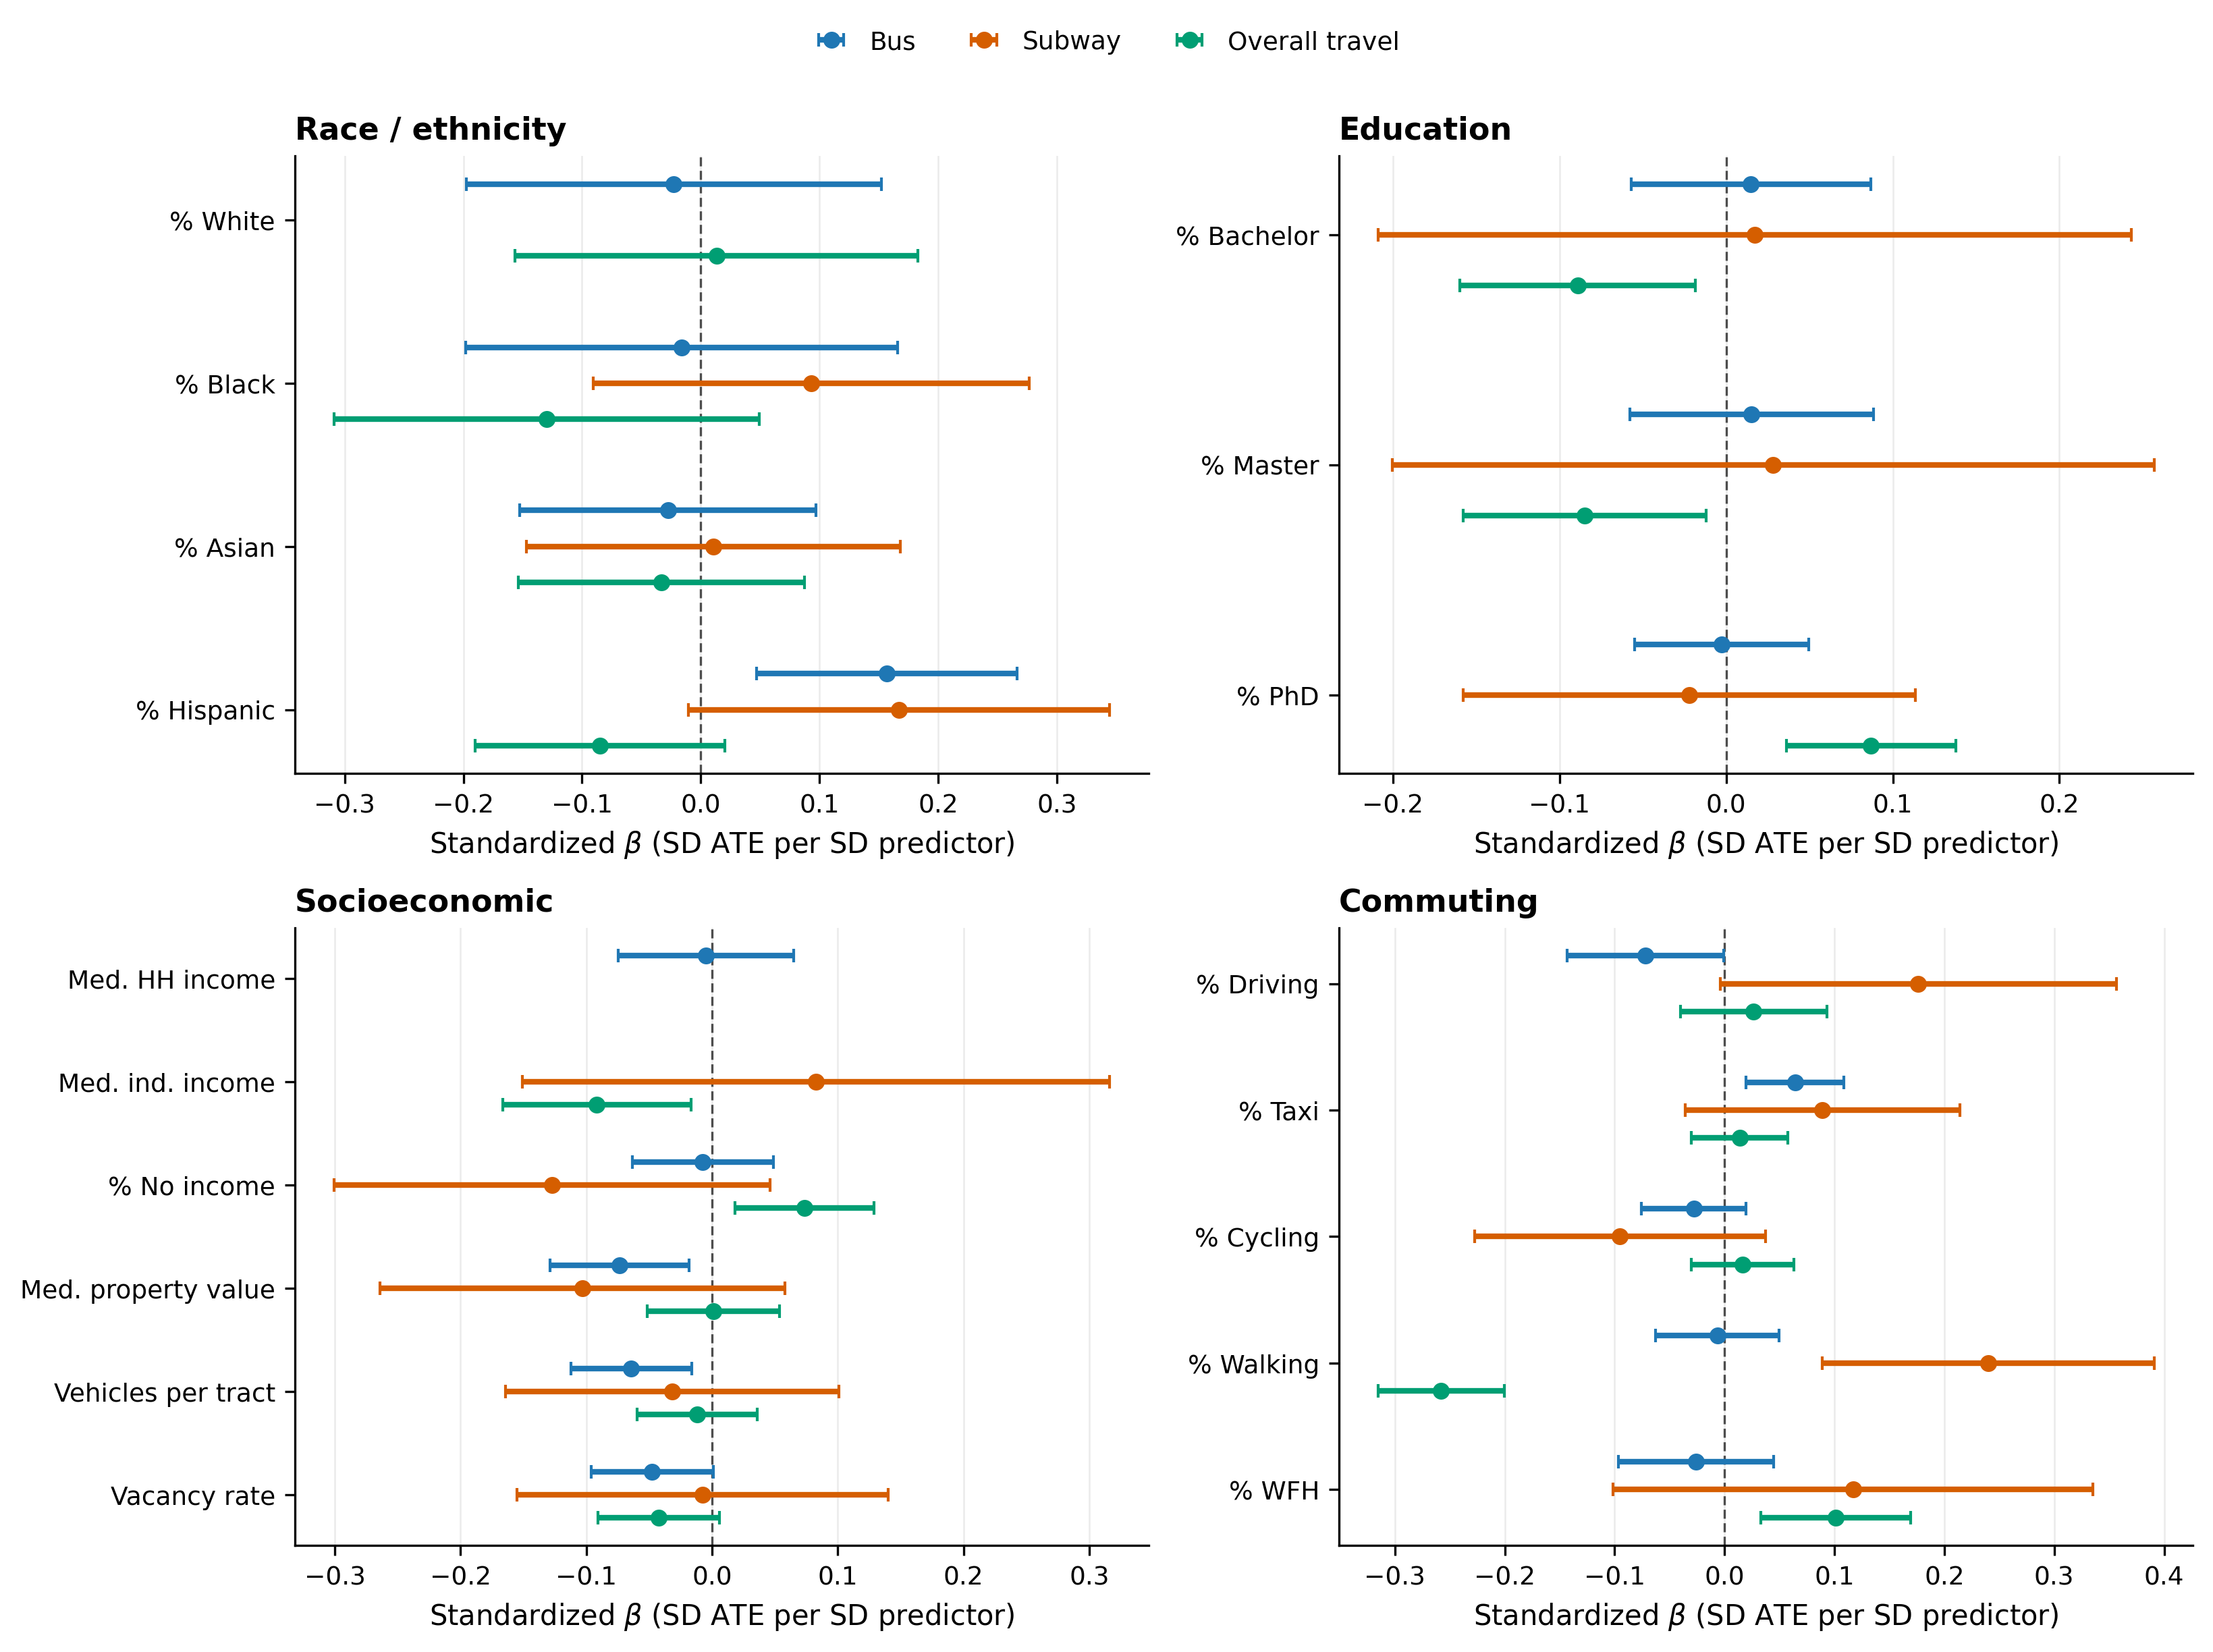

Saved → /home/donghang/nyc_congestion_pricing/outputs/figures/paper/causal/ml_lag_zscored_forest.{pdf,png}


In [6]:
# %% Standardized ML_Lag β by variable group — 4-panel forest plot

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

plt.rcParams.update({
    "font.size": 9,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# --- Load standardized coefficients for the 3 paper modes ---
ROOT = Path("/home/donghang/nyc_congestion_pricing/outputs/figures/paper/causal/ml_lag_zscored")

mode_files = {
    "Bus":            ROOT / "coef_bus_all.csv",
    "Subway":         ROOT / "coef_subway_total.csv",
    "Overall travel": ROOT / "coef_replica_O.csv",
}
mode_colors = {
    "Bus":            "#1F77B4",
    "Subway":         "#D55E00",
    "Overall travel": "#009E73",
}

dfs = {mode: pd.read_csv(p) for mode, p in mode_files.items()}

# --- 4 variable groups ---
groups = {
    "Race / ethnicity":   ["pct_white", "pct_black", "pct_asian", "pct_hispanic"],
    "Education":          ["pct_bachelor", "pct_master", "pct_phd"],
    "Socioeconomic":      ["inc_median_household", "inc_median_ind", "pct_no_inc",
                           "property_value_median", "vehicle_total_imputed", "vacancy_rate"],
    "Commuting":          ["pct_driving", "pct_taxi", "pct_cycle", "pct_walk", "pct_wfh"],
}

# Pretty labels
label_map = {
    "pct_white": "% White",          "pct_black": "% Black",
    "pct_asian": "% Asian",          "pct_hispanic": "% Hispanic",
    "pct_bachelor": "% Bachelor",    "pct_master": "% Master",   "pct_phd": "% PhD",
    "inc_median_household": "Med. HH income",
    "inc_median_ind": "Med. ind. income",
    "pct_no_inc": "% No income",
    "property_value_median": "Med. property value",
    "vehicle_total_imputed": "Vehicles per tract",
    "vacancy_rate": "Vacancy rate",
    "pct_driving": "% Driving",      "pct_taxi": "% Taxi",       "pct_cycle": "% Cycling",
    "pct_walk": "% Walking",         "pct_wfh": "% WFH",
}

# --- 2x2 forest-plot panels ---
fig, axes = plt.subplots(2, 2, figsize=(11, 8), dpi=300, sharex=False)
axes = axes.flatten()

mode_order = list(mode_files.keys())
y_offsets = {m: (i - 1) * 0.22 for i, m in enumerate(mode_order)}  # -0.22, 0, +0.22

for ax, (group_name, var_list) in zip(axes, groups.items()):
    n_vars = len(var_list)
    y_base = np.arange(n_vars)

    for mode in mode_order:
        df = dfs[mode].set_index("variable")
        ys, xs, errs = [], [], []
        for i, v in enumerate(var_list):
            if v not in df.index:
                continue
            row = df.loc[v]
            ys.append(y_base[i] + y_offsets[mode])
            xs.append(row["coef"])
            errs.append(1.96 * row["std_err"])  # 95% CI

        ax.errorbar(
            xs, ys, xerr=errs,
            fmt="o", color=mode_colors[mode], markersize=5,
            elinewidth=2, capsize=2.5, capthick=1.0,
            label=mode, zorder=3,
        )

    ax.axvline(0, color="0.3", lw=0.8, ls=(0, (4, 2)), zorder=1)
    ax.set_yticks(y_base)
    ax.set_yticklabels([label_map.get(v, v) for v in var_list])
    ax.invert_yaxis()
    ax.set_xlabel(r"Standardized $\beta$ (SD ATE per SD predictor)")
    ax.set_title(group_name, loc="left", pad=6, fontweight="bold")
    ax.grid(axis="x", color="0.92", lw=0.6, zorder=0)
    ax.set_axisbelow(True)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_linewidth(0.8)

# Shared legend at the top
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="upper center", bbox_to_anchor=(0.5, 1.02),
    ncol=3, frameon=False, handlelength=1.4, columnspacing=2.0,
)

plt.tight_layout(rect=[0, 0, 1, 0.97])

out_dir = Path("/home/donghang/nyc_congestion_pricing/outputs/figures/paper/causal")
fig.savefig(out_dir / "ml_lag_zscored_forest.pdf", bbox_inches="tight")
fig.savefig(out_dir / "ml_lag_zscored_forest.png", bbox_inches="tight", dpi=300)
plt.show()
print(f"Saved → {out_dir / 'ml_lag_zscored_forest'}.{{pdf,png}}")